# HW07-ICA Part A :: Models, Tools, and Intent Understanding

COSC 6373 -- Adam Nelson-Archer, 2140122

## Prerequisites

- Install Ollama and pull models:
  - `ollama pull mistral`
  - `ollama pull llava`
- Install Python packages in your environment:
  - `pip install -U langchain langchain-ollama scikit-learn matplotlib pandas`


In [1]:
from __future__ import annotations

import datetime as dt
import re
import socket
from typing import Dict, List

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix

try:
    from langchain_ollama import ChatOllama
    from langchain_core.messages import HumanMessage, SystemMessage
except Exception as e:
    raise ImportError(
        "Missing LangChain/Ollama packages. Install with: "
        "pip install -U langchain langchain-ollama"
    ) from e

OLLAMA_HOST = "127.0.0.1"
OLLAMA_PORT = 11434
OLLAMA_BASE_URL = f"http://{OLLAMA_HOST}:{OLLAMA_PORT}"

INTENTS = [
    "chat",
    "ask_time",
    "memory_write",
    "memory_read",
    "web_search",
    "camera_request",
    "image_analysis_provided",
]

print("Ollama URL:", OLLAMA_BASE_URL)
print("Intents:", INTENTS)


Ollama URL: http://127.0.0.1:11434
Intents: ['chat', 'ask_time', 'memory_write', 'memory_read', 'web_search', 'camera_request', 'image_analysis_provided']


In [2]:
def is_port_open(host: str, port: int, timeout_s: float = 0.5) -> bool:
    s = socket.socket()
    s.settimeout(timeout_s)
    try:
        s.connect((host, port))
        return True
    except OSError:
        return False
    finally:
        try:
            s.close()
        except OSError:
            pass


def get_llm(model_name: str) -> ChatOllama:
    return ChatOllama(model=model_name, base_url=OLLAMA_BASE_URL, temperature=0)


ollama_ok = is_port_open(OLLAMA_HOST, OLLAMA_PORT)
print("Ollama reachable:", ollama_ok)

if ollama_ok:
    llm_text = get_llm("mistral")
    llm_vision = get_llm("llava")
    print("Loaded models: mistral, llava")
else:
    llm_text = None
    llm_vision = None
    print("Start Ollama first to run model cells.")


Ollama reachable: False
Start Ollama first to run model cells.


## Hidden system time/date context + policy table

Part A requires appending hidden current date/time before processing each message.


In [3]:
POLICY_TABLE = pd.DataFrame(
    [
        {"intent": "chat", "partA_behavior": "Use Mistral for normal conversation", "partB_tool_target": "none"},
        {"intent": "ask_time", "partA_behavior": "LLM answers using hidden current date/time system prompt", "partB_tool_target": "none"},
        {"intent": "memory_write", "partA_behavior": "Intent detected and routed only", "partB_tool_target": "long_term_memory_write"},
        {"intent": "memory_read", "partA_behavior": "Intent detected and routed only", "partB_tool_target": "long_term_memory_read"},
        {"intent": "web_search", "partA_behavior": "Intent detected and routed only", "partB_tool_target": "web_search_tool"},
        {"intent": "camera_request", "partA_behavior": "Intent detected and routed only", "partB_tool_target": "camera_capture_and_vlm"},
        {"intent": "image_analysis_provided", "partA_behavior": "Intent detected and routed only", "partB_tool_target": "provided_image_vlm"},
    ]
)


def build_hidden_datetime_system_prompt() -> str:
    now = dt.datetime.now().astimezone()
    return (
        "SYSTEM (hidden): Current local date/time is "
        f"{now.isoformat(timespec='seconds')}. "
        "Use this for time-aware reasoning when needed."
    )


POLICY_TABLE


,intent,partA_behavior,partB_tool_target
0,chat,Use Mistral for normal conversation,none
1,ask_time,LLM answers using hidden current date/time sys...,none
2,memory_write,Intent detected and routed only,long_term_memory_write
3,memory_read,Intent detected and routed only,long_term_memory_read
4,web_search,Intent detected and routed only,web_search_tool
5,camera_request,Intent detected and routed only,camera_capture_and_vlm
6,image_analysis_provided,Intent detected and routed only,provided_image_vlm


## Intent detector

Single-intent assumption is used, as required by Part A.


In [4]:
def keyword_intent_classifier(user_text: str) -> str:
    t = user_text.lower().strip()

    if re.search(r"\b(time|date|day|what time|what's the time|current time)\b", t):
        return "ask_time"
    if re.search(r"\b(remember|store this|save this|note that|memorize)\b", t):
        return "memory_write"
    if re.search(r"\b(recall|what did i tell you|retrieve|what do you remember|remind me)\b", t):
        return "memory_read"
    if re.search(r"\b(search|look up|find online|web|google|verify online)\b", t):
        return "web_search"
    if re.search(r"\b(camera|webcam|take a photo|open camera|snapshot)\b", t):
        return "camera_request"
    if re.search(r"\b(attached image|this image|analyze image|analyze photo|picture i uploaded)\b", t):
        return "image_analysis_provided"
    return "chat"


def classify_intent(user_text: str, llm: ChatOllama | None = None) -> str:
    """Classify intent first. LLM fallback is used only if keyword confidence is weak."""
    intent = keyword_intent_classifier(user_text)
    if intent != "chat" or llm is None:
        return intent

    prompt = (
        "Classify this user message into exactly one label from: "
        f"{INTENTS}. Return only the label.\n"
        f"Message: {user_text}"
    )
    try:
        out = llm.invoke([HumanMessage(content=prompt)]).content.strip().lower()
        if out in INTENTS:
            return out
    except Exception:
        pass
    return "chat"


## Intent classifier evaluation (20 labeled examples)

Part A asks for a small labeled dataset, accuracy, and confusion matrix.


Intent classification accuracy (20 examples): 0.8000


,text,true,pred
0,How does transfer learning work?,chat,chat
1,Explain overfitting in simple terms.,chat,chat
2,What time is it right now?,ask_time,ask_time
3,Can you tell me today's date?,ask_time,ask_time
4,Remember that my student ID is 2140122.,memory_write,memory_write
5,Store this: meeting is at 3 PM Friday.,memory_write,memory_write
6,What did I ask you to remember?,memory_read,memory_write
7,Recall the note I saved earlier.,memory_read,memory_read
8,Search the web for latest CUDA version.,web_search,web_search
9,Look up weather in Houston online.,web_search,web_search


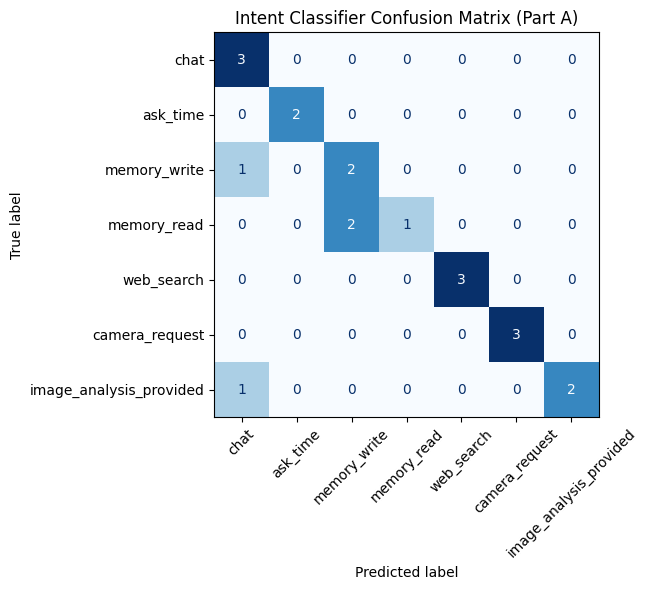

In [5]:
eval_examples: List[Dict[str, str]] = [
    {"text": "How does transfer learning work?", "label": "chat"},
    {"text": "Explain overfitting in simple terms.", "label": "chat"},
    {"text": "What time is it right now?", "label": "ask_time"},
    {"text": "Can you tell me today's date?", "label": "ask_time"},
    {"text": "Remember that my student ID is 2140122.", "label": "memory_write"},
    {"text": "Store this: meeting is at 3 PM Friday.", "label": "memory_write"},
    {"text": "What did I ask you to remember?", "label": "memory_read"},
    {"text": "Recall the note I saved earlier.", "label": "memory_read"},
    {"text": "Search the web for latest CUDA version.", "label": "web_search"},
    {"text": "Look up weather in Houston online.", "label": "web_search"},
    {"text": "Open my webcam and check what you see.", "label": "camera_request"},
    {"text": "Take a photo from the camera.", "label": "camera_request"},
    {"text": "Analyze this image I uploaded.", "label": "image_analysis_provided"},
    {"text": "What is shown in this attached picture?", "label": "image_analysis_provided"},
    {"text": "Tell me a joke about machine learning.", "label": "chat"},
    {"text": "Please save that I prefer Python.", "label": "memory_write"},
    {"text": "Find online references for ResNet50.", "label": "web_search"},
    {"text": "Do you remember my preferred language?", "label": "memory_read"},
    {"text": "Use the camera now.", "label": "camera_request"},
    {"text": "Describe this image for me.", "label": "image_analysis_provided"},
]

y_true = [x["label"] for x in eval_examples]
y_pred = [classify_intent(x["text"], llm_text) for x in eval_examples]

acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred, labels=INTENTS)

print(f"Intent classification accuracy (20 examples): {acc:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=INTENTS)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
ax.set_title("Intent Classifier Confusion Matrix (Part A)")
plt.tight_layout()

pd.DataFrame({"text": [x["text"] for x in eval_examples], "true": y_true, "pred": y_pred})


## Command-line chatbot loop (Part A behavior)

This loop demonstrates:
1. Intent is detected first.
2. Hidden current date/time system prompt is appended.
3. Policy table decides behavior (Part B tool calls are placeholders only).


In [6]:
def part_a_chat_loop():
    if llm_text is None:
        print("Mistral not available. Start Ollama and pull model first.")
        return

    print("Type 'exit' to stop. Part A loop started.")
    while True:
        user_text = input("You: ").strip()
        if user_text.lower() in {"exit", "quit"}:
            print("Session ended.")
            break

        # Required ordering: classify intent before any tool/function behavior.
        intent = classify_intent(user_text, llm_text)
        print(f"[intent={intent}]")

        if intent in {"memory_write", "memory_read", "web_search", "camera_request", "image_analysis_provided"}:
            print("Assistant:", f"Detected intent '{intent}'. Routed by policy table; full tool execution is Part B.")
            continue

        hidden_context = build_hidden_datetime_system_prompt()
        msgs = [
            SystemMessage(content=hidden_context),
            HumanMessage(content=user_text),
        ]
        try:
            reply = llm_text.invoke(msgs).content
        except Exception as e:
            reply = f"LLM error: {type(e).__name__}: {e}"
        print("Assistant:", reply)
        
# after running this cell, you can type part_a_chat_loop() 
# in the console to initiate a chat with the models


In [7]:
part_a_chat_loop()

Mistral not available. Start Ollama and pull model first.


## Acknowledgment

I used a coding assistant (GPT-5.3-Codex) to help scaffold and organize this notebook.
